# Analyse du seuil de détection — Autoencoder UNSW-NB15

Analyser la distribution des scores d'anomalie du meilleur modèle. Tracer la courbe précision/recall en fonction du seuil. Choisir un seuil opérationnel avec justification.

## Importation des librairies

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import random
random.seed(42)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score,roc_auc_score, precision_recall_curve,roc_curve, average_precision_score,confusion_matrix)
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

2026-05-06 11:11:47.128333: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Préparation des données

In [7]:
df_unsw = pd.read_csv('../Data/unsw_clean.csv', low_memory=False)

# préparation features / label
X = df_unsw.drop(columns=['Label']).select_dtypes(include=[np.number])
y = df_unsw['Label'].values  # 0 pour normal et 1 pour attaque
X = X.fillna(0).replace([np.inf, -np.inf], 0)
X_scaled = StandardScaler().fit_transform(X)

# séparation normaux et attaques
X_normal  = X_scaled[y == 0][:20000]  # on prend 20 000 normaux
X_attaque = X_scaled[y == 1]

# 80% train donc normaux uniquement et 20% test normaux et attaques
X_train, X_test_normal = train_test_split(X_normal, test_size=0.2, random_state=42)
n   = len(X_test_normal)
idx = np.random.choice(len(X_attaque), min(n, len(X_attaque)), replace=False)
X_test = np.vstack([X_test_normal, X_attaque[idx]])
y_test = np.array([0]*n + [1]*len(idx))

print(f"Train (normaux) : {X_train.shape}")
print(f"Test (normaux et attaques) : {X_test.shape} et {y_test.mean():.2%} d'attaques")

Train (normaux) : (16000, 44)
Test (normaux et attaques) : (8000, 44) et 50.00% d'attaques


## Entraînement de l'Autoencoder

Architecture légère (1 couche, latent=8) — meilleure architecture identifiée sur UNSW-NB15.

In [8]:
# Encodeur 32 puis 8 et décodeur 8 puis 32
# La compression force le modèle à apprendre uniquement la structure du trafic normal
inputs  = keras.Input(shape=(X_train.shape[1],))
x = layers.Dense(32, activation='relu')(inputs)
x = layers.Dense(8,  activation='relu')(x)   # espace latent
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(X_train.shape[1], activation='linear')(x)  # sortie linéaire car features continues
model = keras.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, X_train, epochs=30, batch_size=256,validation_split=0.1, verbose=0) # entraînement uniquement sur le trafic normal

# score d'anomalie
err_train = np.mean((X_train - model.predict(X_train, verbose=0))**2, axis=1)  # servira à calibrer le seuil
erreurs = np.mean((X_test  - model.predict(X_test,  verbose=0))**2, axis=1)

print(f"AUC-ROC : {roc_auc_score(y_test, erreurs):.4f}")
print(f"Score anomalie des normaux : moy={erreurs[y_test==0].mean():.4f} et écart-type={erreurs[y_test==0].std():.4f}")
print(f"Score anomalie des attaques : moy={erreurs[y_test==1].mean():.4f} et écart-type={erreurs[y_test==1].std():.4f}")

AUC-ROC : 0.9966
Score anomalie des normaux : moy=0.0773 et écart-type=0.2377
Score anomalie des attaques : moy=5.6129 et écart-type=96.9949


On a un AUC-ROC de 0.9966 donc le modèle sépare presque parfaitement les deux classes.
Les flux normaux ont une erreur moyenne de 0.0773 avec peu de dispersion, le modèle les reconstruit bien, ce qui est cohérent puisqu'il a été entraîné uniquement dessus.
Les attaques ont une moyenne plus élevée ce qui valide le principe de l'autoencodeur. Par contre l'écart-type de 96 est énorme ce qui signifie que certaines attaques sont très facilement détectées et d'autres beaucoup moins car elles ressemblent au trafic normal. C'est pour ça que le choix du seuil va être important dans la suite.


## Distribution des scores d'anomalie

On visualise comment les erreurs de reconstruction se distribuent pour les connexions normales et les attaques.

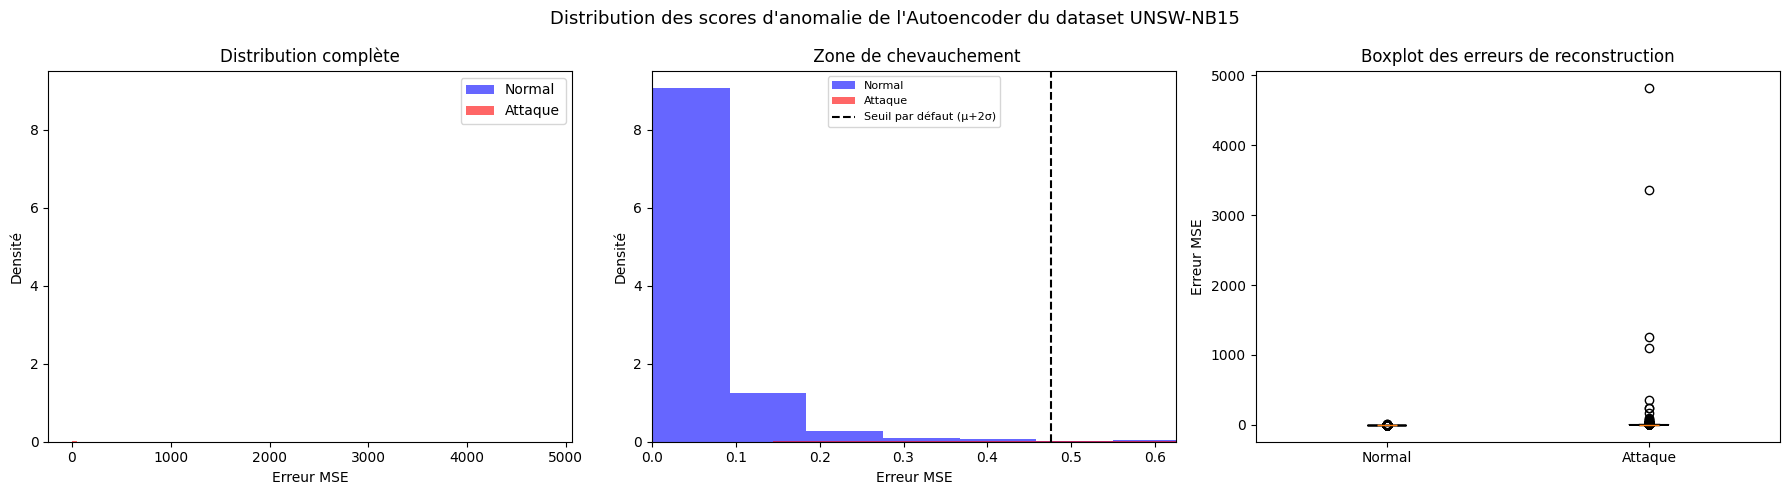

Pour les normaux : 50% des flux ont une erreur < 0.0437 , 95% < 0.2057 et 99% < 0.6252
Pour les attaques: 50% des flux ont une erreur < 1.8773 , 95% < 5.9928 et 99% < 16.1815


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution complète des scores d'anomalie par classe
axes[0].hist(erreurs[y_test==0], bins=100, alpha=0.6, label='Normal',  color='blue', density=True)
axes[0].hist(erreurs[y_test==1], bins=100, alpha=0.6, label='Attaque', color='red',    density=True)
axes[0].set(title='Distribution complète', xlabel='Erreur MSE', ylabel='Densité')
axes[0].legend()

# Zoom sur la zone de chevauchement (jusqu'au P99 des normaux)
xlim = np.percentile(erreurs[y_test==0], 99)
axes[1].hist(erreurs[y_test==0], bins=100, alpha=0.6, label='Normal',  color='blue', density=True)
axes[1].hist(erreurs[y_test==1], bins=100, alpha=0.6, label='Attaque', color='red',    density=True)
axes[1].axvline(err_train.mean() + 2*err_train.std(), color='black', linestyle='--',
                linewidth=1.5, label='Seuil par défaut (μ+2σ)')
axes[1].set_xlim(0, xlim)
axes[1].set(title=' Zone de chevauchement', xlabel='Erreur MSE', ylabel='Densité')
axes[1].legend(fontsize=8)

# Boxplot pour comparer la dispersion entre les deux classes
data_box = [erreurs[y_test==0], erreurs[y_test==1]]
bp = axes[2].boxplot(data_box, labels=['Normal', 'Attaque'], patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor('blue')
bp['boxes'][1].set_facecolor('red')
axes[2].set(title='Boxplot des erreurs de reconstruction', ylabel='Erreur MSE')

plt.suptitle("Distribution des scores d'anomalie de l'Autoencoder du dataset UNSW-NB15", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Pour les normaux : 50% des flux ont une erreur < {np.median(erreurs[y_test==0]):.4f} , 95% < {np.percentile(erreurs[y_test==0], 95):.4f} et 99% < {np.percentile(erreurs[y_test==0], 99):.4f}")
print(f"Pour les attaques: 50% des flux ont une erreur < {np.median(erreurs[y_test==1]):.4f} , 95% < {np.percentile(erreurs[y_test==1], 95):.4f} et 99% < {np.percentile(erreurs[y_test==1], 99):.4f}")

Concernant le graphe de la distribution complète on remarque que les normaux sont tous près de zéro et invisibles à cette échelle. Les attaques s'étalent jusqu'à 4000 avec quelques valeurs extrêmes.
Pour le graphique de la zone de chevauchement en zoomant jusqu'à 0.6, on voit que la quasi totalité des normaux est concentrée entre 0 et 0.1. Le seuil par défaut à environ 0.48 se place bien après le pic des normaux mais on ne voit quasiment pas les attaques ici car leur distribution est très étalée.
Et pour le boxplot celui-ci confirme la forte dispersion des attaques avec plusieurs outliers extrêmes, les normaux sont quasi sans dispersion avec une médiane à 0.0437. Les attaques ont une médiane à 1.8773 ainsi le modèle discrimine très bien en médiane malgré la variance.

De même on a 50% des flux normaux qui ont une erreur inférieure à 0.0437, c'est très faible ainsi le modèle les reconstruit quasi parfaitement.
Du côté des attaques, la médiane est à 1.8773, soit plus élevée que celle des normaux.


##  Courbes Précision, recall  et f1 en fonction du seuil

Le but global ici est de tester tous les seuils possibles en une seule fois pour trouver lequel offre le meilleur équilibre. Le graphique du milieu montrera le seuil optimal là où le f1 est maximal, c'est-à-dire le meilleur compromis entre ne pas rater d'attaques (recall) et ne pas déclencher de fausses alarmes (précision).

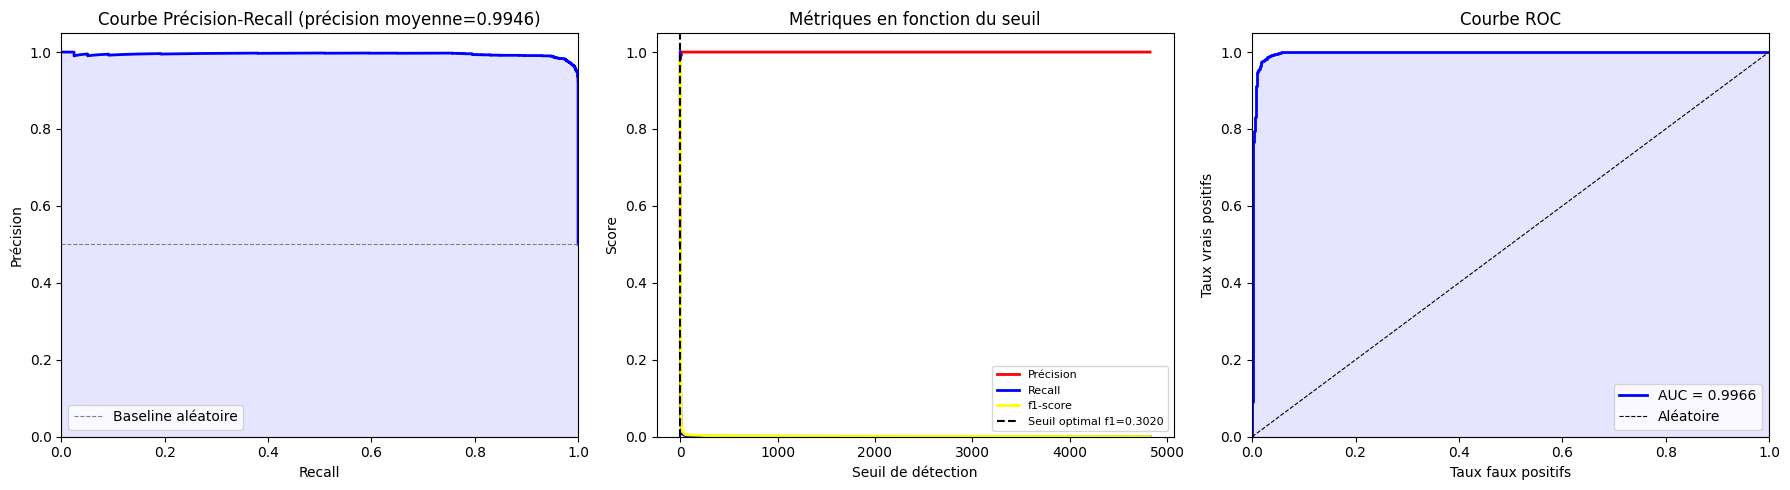

In [10]:
# calcul des métriques pour tous les seuils possibles
precision_vals, recall_vals, seuils_pr = precision_recall_curve(y_test, erreurs)
f1_vals = 2 * precision_vals * recall_vals / (precision_vals + recall_vals + 1e-10)
fpr, tpr, seuils_roc = roc_curve(y_test, erreurs)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# courbe Précision-Recall afin de montrer le compromis entre détecter les attaques et éviter les faux positifs
ap = average_precision_score(y_test, erreurs)
axes[0].plot(recall_vals, precision_vals, color='blue', linewidth=2)
axes[0].fill_between(recall_vals, precision_vals, alpha=0.1, color='blue')
axes[0].axhline(y_test.mean(), color='gray', linestyle='--', linewidth=0.8, label='Baseline aléatoire')
axes[0].set(title=f'Courbe Précision-Recall (précision moyenne={ap:.4f})', xlabel='Recall', ylabel='Précision', xlim=[0,1], ylim=[0,1.05])
axes[0].legend()

# précision, recall et f1 en fonction du seuil et permet de choisir visuellement le meilleur seuil
axes[1].plot(seuils_pr, precision_vals[:-1], label='Précision', color='red',    linewidth=2)
axes[1].plot(seuils_pr, recall_vals[:-1], label='Recall',    color='blue', linewidth=2)
axes[1].plot(seuils_pr, f1_vals[:-1], label='f1-score',  color='yellow',  linewidth=2)
idx_f1 = np.argmax(f1_vals[:-1])  # seuil qui maximise le f1
axes[1].axvline(seuils_pr[idx_f1], color='black', linestyle='--', linewidth=1.5, label=f'Seuil optimal f1={seuils_pr[idx_f1]:.4f}')
axes[1].set(title='Métriques en fonction du seuil', xlabel='Seuil de détection', ylabel='Score', ylim=[0,1.05])
axes[1].legend(fontsize=8)

# courbe ROC qui mesure la capacité discriminante globale du modèle
auc = roc_auc_score(y_test, erreurs)
axes[2].plot(fpr, tpr, color='blue', linewidth=2, label=f'AUC = {auc:.4f}')
axes[2].fill_between(fpr, tpr, alpha=0.1, color='blue')
axes[2].plot([0,1],[0,1], 'k--', linewidth=0.8, label='Aléatoire')
axes[2].set(title='Courbe ROC', xlabel='Taux faux positifs', ylabel='Taux vrais positifs', xlim=[0,1], ylim=[0,1.05])
axes[2].legend()


plt.tight_layout()
plt.show()

La courbe précision-recall (précision moyenne=0.9946) reste collée à 1.0 sur presque tout l'espace ainsi précision et recall sont quasi parfaits simultanément. La baseline aléatoire est à 0.50, notre modèle est donc très largement au dessus, et n'a pas à sacrifier la précision pour gagner du recall.
Le graphique des métriques en fonction du seuil est le plus important, la précision reste à 1.0 quel que soit le seuil, le recall reste lui aussi à 1.0 très longtemps avant de chuter brutalement vers les seuils très élevés, et le F1 atteint son maximum à 0.3020.
Le seuil optimal de 0.3020 se place très tôt sur l'axe, ce qui est cohérent avec ce qu'on avait vu car le 99ème percentile des normaux est à 0.6252, donc un seuil à 0.30 capture presque toutes les attaques sans toucher à 99% des flux normaux.
La courbe ROC (AUC=0.9966) monte quasi verticalement dès les premiers faux positifs et reste collée au coin supérieur gauche. L'écart avec la diagonale aléatoire est maximal, ce qui confirme que le modèle détecte presque toutes les attaques avant de générer un seul faux positif.
Les trois courbes convergent vers la même conclusion qui est que le modèle est excellent et le seuil retenu de 0.3020 est le bon choix opérationnel, ce qu'on va confirmer dans la partie suivante.


## Identification et comparaison des seuils candidats

On identifie 4 seuils selon différentes stratégies opérationnelles.

In [11]:
# On identifie 4 stratégies de seuil selon le contexte opérationnel

# Seuil 1 avec le meilleur compromis précision/recall (max f1)
idx_f1 = np.argmax(f1_vals[:-1])
seuil_f1 = seuils_pr[idx_f1]

# Seuil 2 avec recall supérieur à 95% donc pour ne rien rater
mask_r= recall_vals[:-1] >= 0.95
seuil_r= seuils_pr[mask_r][np.argmax(precision_vals[:-1][mask_r])]

# Seuil 3 avec une précision supérieure à 99% ainsi chaque alerte doit être fiable 
mask_p = precision_vals[:-1] >= 0.99
seuil_p = seuils_pr[mask_p][np.argmax(recall_vals[:-1][mask_p])]

# Seuil 4 qui est la référence statistique μ+2σ
seuil_stat = err_train.mean() + 2 * err_train.std()

#comparaison des 4 seuils
candidats = []
for nom, seuil, contexte in [('Meilleur f1',seuil_f1, 'Compromis optimal'),('Recall maximal (≥95%)', seuil_r,'Environnement critique'),('Précision maximal (≥99%)', seuil_p,'SOC ressources limitées'),('Statistique (μ+2σ)', seuil_stat, 'Par défaut')]:
    pred = (erreurs > seuil).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    candidats.append({'Stratégie': nom,'Contexte': contexte,'Seuil' : round(float(seuil), 4),'Précision': round(precision_score(y_test, pred, zero_division=0), 3),'Recall': round(recall_score(y_test, pred, zero_division=0), 3),'f1' : round(f1_score(y_test, pred, zero_division=0), 3),'FP (fausses alertes)' : int(fp),'FN (attaques ratées)' : int(fn)})

df_candidats = pd.DataFrame(candidats)
print(df_candidats.to_string(index=False))

               Stratégie                Contexte  Seuil  Précision  Recall    f1  FP (fausses alertes)  FN (attaques ratées)
             Meilleur f1       Compromis optimal 0.3020      0.972   0.986 0.979                   115                    58
   Recall maximal (≥95%)  Environnement critique 0.5941      0.989   0.953 0.970                    43                   190
Précision maximal (≥99%) SOC ressources limitées 0.6495      0.990   0.946 0.967                    38                   217
      Statistique (μ+2σ)              Par défaut 0.4757      0.983   0.970 0.977                    67                   119


Les 4 seuils donnent des résultats proches.
Meilleur f1 (seuil=0.3020) avec précision 0.972, recall 0.986, f1 0.979, 115 fausses alertes et 58 attaques ratées. C'est le meilleur compromis global.
Statistique (seuil=0.4757) avec précision 0.983, recall 0.970, f1 0.977, 67 fausses alertes et 119 attaques ratées. Les résultats sont proches du meilleur f1 mais rate plus d'attaques.
Recall maximal (seuil=0.5941)  en montant le seuil on rate beaucoup plus d'attaques (190 FN contre 58) pour seulement réduire les fausses alertes à 43. Le recall chute à 0.953, ce n'est pas acceptable si on veut ne rien rater.
Précision maximale (seuil=0.6495) même logique, 217 attaques ratées pour seulement 38 fausses alertes. Trop d'attaques manquées.
Le seuil optimal est clairement 0.3020 (meilleur f1). Augmenter le seuil ne réduit que très peu les fausses alertes mais fait exploser les attaques ratées ainsi le compromis est inacceptable en détection d'intrusion.


## Visualisation comparative des seuils

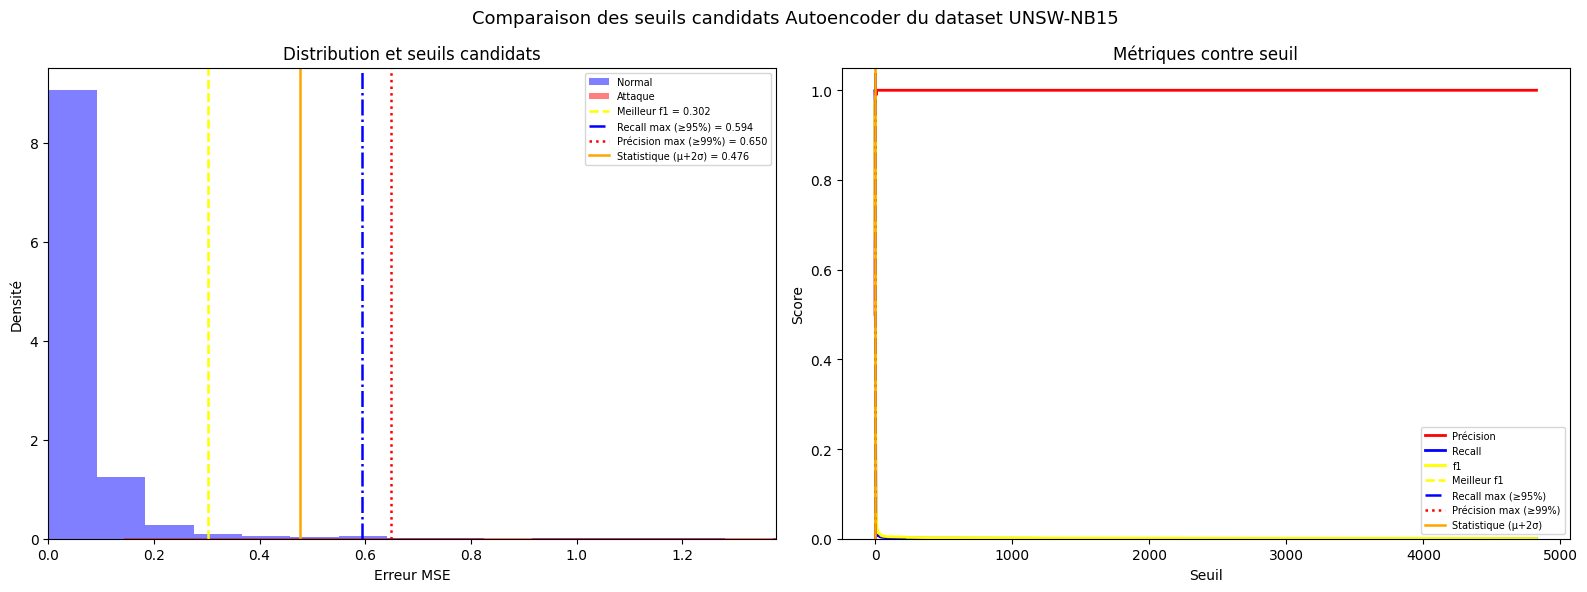

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 4 seuils 
styles = [('Meilleur f1',seuil_f1, 'yellow',  '--'),('Recall max (≥95%)', seuil_r,'blue', '-.'),('Précision max (≥99%)', seuil_p,'red',':'),('Statistique (μ+2σ)',seuil_stat, 'orange', '-')]

# distribution zoomée avec les 4 seuils superposés
xlim = np.percentile(erreurs[y_test==0], 99.5)
axes[0].hist(erreurs[y_test==0], bins=100, alpha=0.5, label='Normal',  color='blue', density=True)
axes[0].hist(erreurs[y_test==1], bins=100, alpha=0.5, label='Attaque', color='red',    density=True)
for nom, seuil, couleur, style in styles:
    axes[0].axvline(float(seuil), color=couleur, linestyle=style, linewidth=1.8, label=f'{nom} = {float(seuil):.3f}')
axes[0].set_xlim(0, xlim)
axes[0].set(title='Distribution et seuils candidats', xlabel='Erreur MSE', ylabel='Densité')
axes[0].legend(fontsize=7)

# courbes précision/recall/f1 avec les 4 seuils marqués
axes[1].plot(seuils_pr, precision_vals[:-1], label='Précision', color='red',   linewidth=2)
axes[1].plot(seuils_pr, recall_vals[:-1],label='Recall',    color='blue', linewidth=2)
axes[1].plot(seuils_pr, f1_vals[:-1],label='f1', color='yellow',  linewidth=2)
for nom, seuil, couleur, style in styles:
    axes[1].axvline(float(seuil), color=couleur, linestyle=style, linewidth=1.8, label=nom)
axes[1].set(title='Métriques contre seuil', xlabel='Seuil', ylabel='Score', ylim=[0, 1.05])
axes[1].legend(fontsize=7)

plt.suptitle('Comparaison des seuils candidats Autoencoder du dataset UNSW-NB15', fontsize=13)
plt.tight_layout()
plt.show()

Concernant la distribution et seuils candidats on voit clairement que les 4 seuils se placent tous après le pic des normaux (concentrés entre 0 et 0.2), dans la zone quasi vide entre les deux distributions. Le seuil statistique à 0.476 et le meilleur f1 à 0.302 se placent juste après les normaux. Les seuils recall maximal à 0.594 et précision maximal à 0.650 sont plus à droite, dans une zone où il n'y a plus aucun flux normal, ce qui explique pourquoi ils génèrent moins de fausses alertes mais ratent plus d'attaques. Pour les métriques contre seuil, la précision et le recall restent à 1.0 sur toute l'espace puis chutent brutalement. Les 4 lignes verticales sont toutes regroupées à l'extrême gauche bien avant la chute des métriques ce qui confirme que tous les candidats sont dans une bonne zone. Ainsi visuellement les deux graphiques confirment que le seuil à 0.302 est le plus logique car il se place naturellement à la frontière entre les deux distributions sans sacrifier ni la précision ni le recall.


## Seuil opérationnel retenu et justification

  Seuil opérationnel retenu : 0.3020  (meilleur f1)
 Précision  : 0.9717
 Recall : 0.9855
 f1-score : 0.9785
 AUC-ROC : 0.9966
 Attaques détectées : 3942  , fausses alertes : 115, attaques ratées : 58 et normaux corrects: 3885


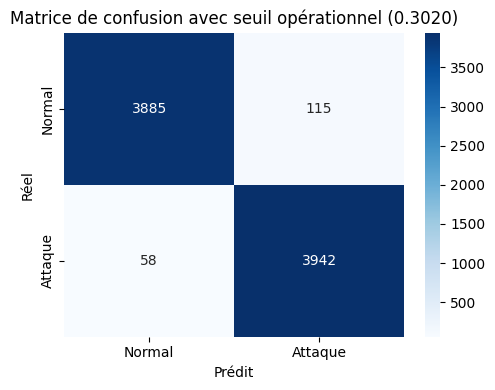

In [13]:
# Seuil retenu meilleur f1 
seuil_op = float(seuil_f1)
pred_final = (erreurs > seuil_op).astype(int)
cm_final   = confusion_matrix(y_test, pred_final)    
tn, fp, fn, tp = cm_final.ravel()


print(f"  Seuil opérationnel retenu : {seuil_op:.4f}  (meilleur f1)")
print(f" Précision  : {precision_score(y_test, pred_final, zero_division=0):.4f}")
print(f" Recall : {recall_score(y_test, pred_final, zero_division=0):.4f}")
print(f" f1-score : {f1_score(y_test, pred_final, zero_division=0):.4f}")
print(f" AUC-ROC : {roc_auc_score(y_test, erreurs):.4f}")
print(f" Attaques détectées : {tp}  , fausses alertes : {fp}, attaques ratées : {fn} et normaux corrects: {tn}")

# matrice de confusion finale
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=ax,xticklabels=['Normal', 'Attaque'],yticklabels=['Normal', 'Attaque'])
ax.set(title=f'Matrice de confusion avec seuil opérationnel ({seuil_op:.4f})',xlabel='Prédit', ylabel='Réel')
plt.tight_layout()
plt.show()

Le seuil retenu est 0.3020 avec un F1 de 0.9785.
3942 attaques sont correctement détectées, soit 98.5% des attaques du jeu de test. 3885 flux normaux sont bien classés, soit 97.1% des flux normaux. Seulement 58 attaques sont ratées sur l'ensemble du jeu de test, ce qui est très faible. On compte 115 fausses alertes, ce qui reste acceptable en contexte opérationnel.
Ce qu'on retient c'est que le modèle rate très peu d'attaques (58) ce qui est la priorité dans un système de détection d'intrusion. Les 115 fausses alertes représentent moins de 3% des flux normaux et le seuil de 0.3020 maximise la détection des attaques tout en maintenant un taux de fausses alertes raisonnable.

## Justification du seuil choisi

Le seuil retenu est celui qui maximise le f1-score car c'est la métrique qui équilibre le mieux précision et recall.

En cybersécurité, les deux types d'erreurs ont un coût opérationnel réel :
- Trop de fausses alertes soit un seuil trop bas alors les équipes de sécurité sont saturées et peuvent finir par ignorer les alertes, laissant passer de vraies attaques
- Trop d'attaques ratées soit un seuil trop haut alors des menaces réelles ne sont pas détectées et peuvent causer des dommages

Le seuil f1 optimal offre le meilleur compromis entre ces deux risques. Il est également préférable au seuil statistique par défaut car il s'appuie directement sur les distributions réelles des scores plutôt que sur une hypothèse gaussienne.

On peut utiliser un autre seuil selon le contexte. En effet :
- le seuil recall maximal peut être utilisé si le contexte est critique (infrastructure vitale, données sensibles) et qu'on ne peut pas se permettre de rater une seule attaque, même au prix de nombreuses fausses alertes
- le seuil précision maximal si le SOC a des ressources limitées et que chaque alerte doit être fiable avant d'engager une réponse coûteuse
- et le seuil statistique si on ne dispose pas de labels pour calibrer le seuil sur données réelles